⏳ PM2.5 Hava Kirliliği İşlemi Başlıyor... (2020-01-01 - 2023-01-15)
📡 API'den İndiriliyor (Tallinn - Estonia)...vador).....ds)...
❌ Hata (Tallinn - Estonia): failed to request 'https://air-quality-api.open-meteo.com/v1/air-quality': {'reason': 'Minutely API request limit exceeded. Please try again in one minute.', 'error': True}
📡 API'den İndiriliyor (Suva - Fiji)...
❌ Hata (Suva - Fiji): failed to request 'https://air-quality-api.open-meteo.com/v1/air-quality': {'error': True, 'reason': 'Minutely API request limit exceeded. Please try again in one minute.'}
📡 API'den İndiriliyor (Helsinki - Finland)...
❌ Hata (Helsinki - Finland): failed to request 'https://air-quality-api.open-meteo.com/v1/air-quality': {'error': True, 'reason': 'Minutely API request limit exceeded. Please try again in one minute.'}
📡 API'den İndiriliyor (Papeete - French Polynesia)...
❌ Hata (Papeete - French Polynesia): failed to request 'https://air-quality-api.open-meteo.com/v1/air-quality': {'reason': 'Minutely 

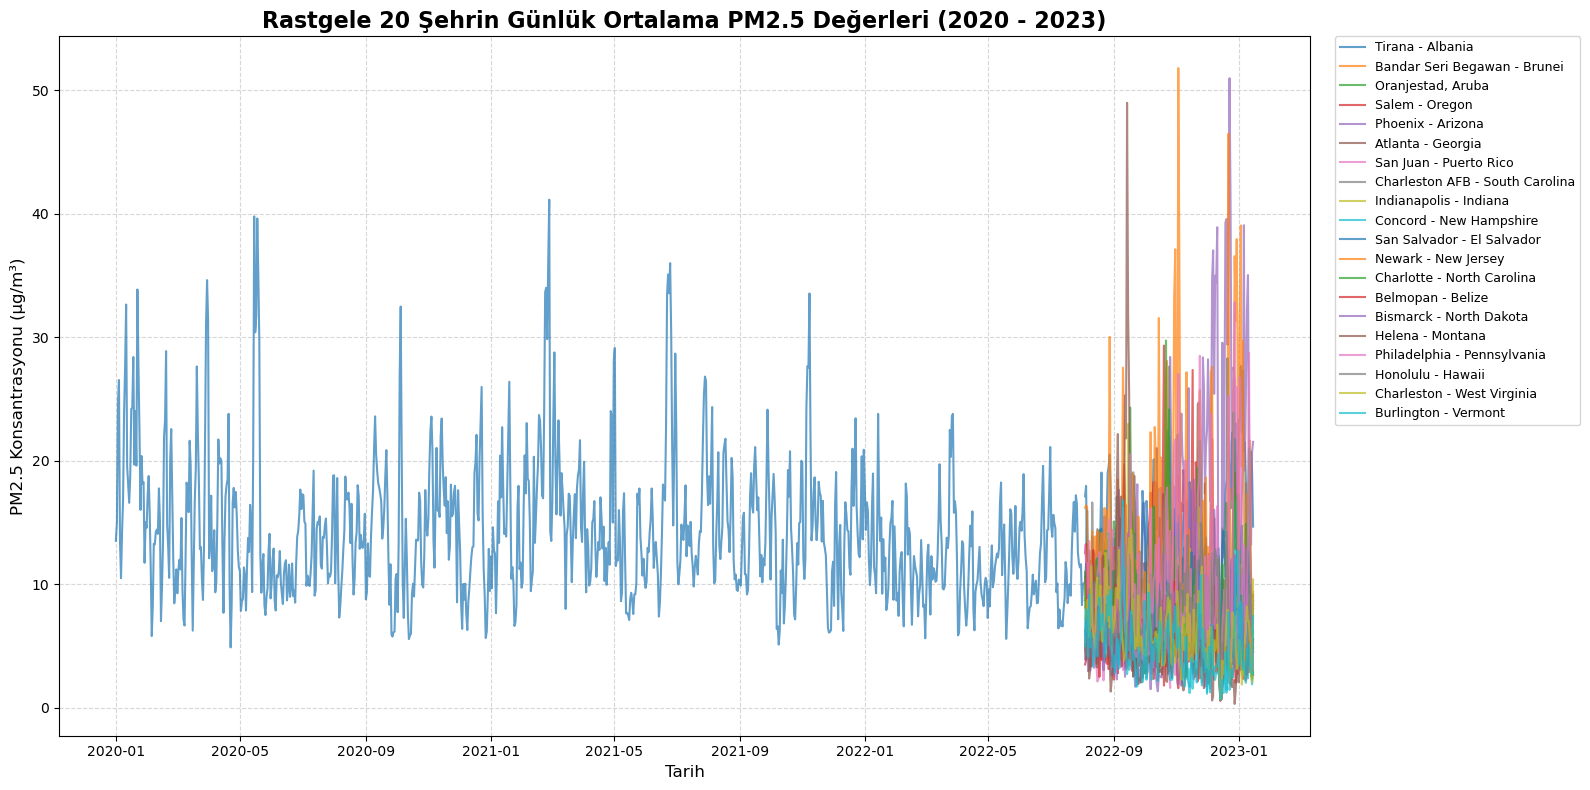


🏁 İşlem tamamlandı.


In [2]:
import openmeteo_requests
import requests_cache
from retry_requests import retry
import pandas as pd
import os
import re
import time
import random
import matplotlib.pyplot as plt

# --- 1. AYARLAR ---
START_DATE = "2020-01-01"
END_DATE = "2023-01-15" 

FILE_PM25 = "Rapor_Gunluk_PM25_Ortalama_1111Gun.xlsx"
CACHE_FOLDER = "sehir_verileri_pm25_gunluk"
os.makedirs(CACHE_FOLDER, exist_ok=True)

# API İstemci Kurulumu (Senin bulduğun yöntem)
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Şehir Listesi (Aynı liste)
ERA5_CITY_AREAS = {
    # ABD
    'Birmingham - Alabama': '33.7700/-87.0600/33.2700/-86.5600',
    'Anchorage - Alaska': '61.4200/-150.1700/60.9200/-149.6700',
    'American Samoa - Pago Pago': '-14.0200/-170.9500/-14.5200/-170.4500',
    'Phoenix - Arizona': '33.7400/-112.3500/33.2400/-111.8500',
    'Little Rock - Arkansas': '34.9900/-92.5300/34.4900/-92.0300',
    'Sacramento - California': '38.7700/-121.7500/38.2700/-121.2500',
    'Denver - Colorado': '39.9800/-105.1300/39.4800/-104.6300',
    'Bridgeport - Connecticut': '41.4300/-73.4400/40.9300/-72.9400',
    'Dover - Delaware': '39.3600/-75.7600/38.8600/-75.2600',
    'Washington - District of Columbia': '39.1500/-77.2800/38.6500/-76.7800',
    'Tallahassee - Florida': '30.6500/-84.5500/30.1500/-84.0500',
    'Atlanta - Georgia': '34.0000/-84.6400/33.5000/-84.1400',
    'Guam': '13.7300/144.5700/13.2300/145.0700',
    'Honolulu - Hawaii': '21.5800/-158.0800/21.0800/-157.5800',
    'Boise - Idaho': '43.8700/-116.4500/43.3700/-115.9500',
    'Chicago - Illinois': '41.9700/-87.9700/41.4700/-87.4700',
    'Indianapolis - Indiana': '39.9700/-86.3700/39.4700/-85.8700',
    'Des Moines - Iowa': '41.8800/-93.8200/41.3800/-93.3200',
    'Topeka - Kansas': '39.2600/-95.9600/38.7600/-95.4600',
    'Frankfort - Kentucky': '38.4500/-85.1200/37.9500/-84.6200',
    'New Orleans - Louisiana': '30.2000/-90.2000/29.7000/-89.7000',
    'Augusta - Maine': '44.5600/-69.9600/44.0600/-69.4600',
    'Baltimore - Maryland': '39.5400/-76.8600/39.0400/-76.3600',
    'Boston - Massachusetts': '42.6100/-71.3100/42.1100/-70.8100',
    'Lansing - Michigan': '42.9700/-84.7600/42.4700/-84.2600',
    'Saint Paul - Minnesota': '45.1900/-93.3500/44.6900/-92.8500',
    'Jackson - Mississippi': '32.5800/-90.3000/32.0800/-89.8000',
    'Jefferson City - Missouri': '38.7700/-92.3600/38.2700/-91.8600',
    'Helena - Montana': '46.8800/-112.2600/46.3800/-111.7600',
    'Omaha - Nebraska': '41.4800/-96.2200/40.9800/-95.7200',
    'Carson City - Nevada': '39.4100/-120.0200/38.9100/-119.5200',
    'Concord - New Hampshire': '43.4000/-71.7500/42.9000/-71.2500',
    'Newark - New Jersey': '40.9700/-74.3700/40.4700/-73.8700',
    'Santa Fe - New Mexico': '35.9800/-106.1800/35.4800/-105.6800',
    'New York - New York': '40.9600/-74.2500/40.4600/-73.7500',
    'Charlotte - North Carolina': '35.4200/-80.9300/34.9200/-80.4300',
    'Bismarck - North Dakota': '47.0500/-101.0400/46.5500/-100.5400',
    'Saipan, Northern Mariana Islands': '15.4200/145.7200/14.9200/146.2200',
    'Columbus - Ohio': '40.1000/-83.1000/39.6000/-82.6000',
    'Oklahoma City - Oklahoma': '35.7700/-97.7700/35.2700/-97.2700',
    'Salem - Oregon': '45.1900/-123.2800/44.6900/-122.7800',
    'Philadelphia - Pennsylvania': '40.2300/-75.4500/39.7300/-74.9500',
    'San Juan - Puerto Rico': '18.6600/-66.2100/18.1600/-65.7100',
    'Providence - Rhode Island': '41.9200/-71.6000/41.4200/-71.1000',
    'Charleston AFB - South Carolina': '33.1400/-80.2900/32.6400/-79.7900',
    'Columbia - South Dakota': '45.8500/-98.5500/45.3500/-98.0500',
    'Memphis - Tennessee': '35.3200/-90.2700/34.8200/-89.7700',
    'Austin - Texas': '30.5200/-97.9900/30.0200/-97.4900',
    'Salt Lake City - Utah': '40.9800/-112.0200/40.4800/-111.5200',
    'Burlington - Vermont': '44.7300/-73.4600/44.2300/-72.9600',
    'Virgin Islands': '18.5800/-65.1500/18.0800/-64.6500',
    'Richmond - Virginia': '37.7500/-77.6200/37.2500/-77.1200',
    'Seattle - Washington': '47.8200/-122.5300/47.3200/-122.0300',
    'Charleston - West Virginia': '38.5800/-81.8200/38.0800/-81.3200',
    'Milwaukee - Wisconsin': '43.2000/-88.1000/42.7000/-87.6000',
    'Cheyenne - Wyoming': '41.3800/-105.0200/40.8800/-104.5200',

    # Uluslararası
    'Tirana - Albania': '41.5700/19.5600/41.0700/20.0600',
    'Andorra': '42.7600/1.2700/42.2600/1.7700',
    'St. John\'s, Antigua and Barbuda': '17.3700/-62.0800/16.8700/-61.5800',
    'Oranjestad, Aruba': '12.8000/-70.2800/12.3000/-69.7800',
    'Vienna - Austria': '48.4500/16.1200/47.9500/16.6200',
    'Nassau, The Bahamas': '25.2600/-77.5800/24.7600/-77.0800',
    'Manama - Bahrain': '26.4200/50.4800/25.9200/50.9800',
    'Brussels - Belgium': '51.0500/4.0200/50.5500/4.5200',
    'Belmopan - Belize': '17.5000/-89.0100/17.0000/-88.5100',
    'Sarajevo - Bosnia and Herzegovina': '44.1000/18.1600/43.6000/18.6600',
    'Road Town - British Virgin Islands': '18.6700/-64.8700/18.1700/-64.3700',
    'Bandar Seri Begawan - Brunei': '5.1400/114.6900/4.6400/115.1900',
    'Praia - Cape Verde': '15.1500/-23.6000/14.6500/-23.1000',
    'Zagreb - Croatia': '46.0600/15.7300/45.5600/16.2300',
    'Willemstad - Curacao': '12.3700/-69.1000/11.8700/-68.6000',
    'Nicosia - Cyprus': '35.3200/33.1700/34.8200/33.6700',
    'Prague - Czechia': '50.3000/14.1700/49.8000/14.6700',
    'Copenhagen - Denmark': '55.9200/12.3200/55.4200/12.8200',
    'Roseau - Dominica': '15.5500/-61.6300/15.0500/-61.1300',
    'San Salvador - El Salvador': '13.9400/-89.4700/13.4400/-88.9700',
    'Tallinn - Estonia': '59.6400/24.5100/59.1400/25.0100',
    'Suva - Fiji': '-17.9600/178.2900/-18.4600/178.7900',
    'Helsinki - Finland': '60.4200/24.7500/59.9200/25.2500',
    'Papeete - French Polynesia': '-17.2200/-149.7700/-17.7200/-149.2700',
    'Gibraltar': '36.3200/-5.5500/35.8200/-5.0500',
    'St. George\'s - Grenada': '12.3000/-61.9500/11.8000/-61.4500',
    'Port-au-Prince - Haiti': '18.7900/-72.5800/18.2900/-72.0800',
    'Hong Kong': '22.5700/113.9700/22.0700/114.4700',
    'Budapest - Hungary': '47.7400/18.7900/47.2400/19.2900',
    'Reykjavik - Iceland': '64.3000/-22.0300/63.8000/-21.5300',
    'Dublin - Ireland': '53.5800/-6.4000/53.0800/-5.9000',
    'Douglas - Isle of Man': '54.3200/-4.6200/53.8200/-4.1200',
    'Jerusalem - Israel': '32.0700/35.0800/31.5700/35.5800',
    'Kingston - Jamaica': '18.2400/-76.9900/17.7400/-76.4900',
    'Tarawa - Kiribati': '1.6700/172.7800/1.1700/173.2800',
    'Pristina - Kosovo': '42.9100/20.9100/42.4100/21.4100',
    'Kuwait': '29.6200/47.7800/29.1200/48.2800',
    'Riga - Latvia': '57.2000/24.0000/56.7000/24.5000',
    'Vaduz - Liechtenstein': '47.3200/9.3200/46.8200/9.8200',
    'Vilnius - Lithuania': '54.9700/25.0700/54.4700/25.5700',
    'Luxembourg': '49.8600/5.8800/49.3600/6.3800',
    'Macao': '22.4400/113.2900/21.9400/113.7900',
    'Male - Maldives': '4.3200/73.4800/3.8200/73.9800',
    'Valletta - Malta': '35.9400/14.3600/35.4400/14.8600',
    'Majuro - Marshall Islands': '7.3800/171.1800/6.8800/171.6800',
    'Port Louis - Mauritius': '-19.9600/57.3600/-20.4600/57.8600',
    'Weno - Micronesia': '7.6000/151.7800/7.1000/152.2800',
    'Monaco': '43.9800/7.1700/43.4800/7.6700',
    'Amsterdam - Netherlands': '52.6200/4.6500/52.1200/5.1500',
    'Nouméa - New Caledonia': '-22.0300/166.2000/-22.5300/166.7000',
    'Skopje - North Macedonia': '42.2500/21.1800/41.7500/21.6800',
    'Oslo - Norway': '60.1000/10.3700/59.6000/10.8700',
    'Doha - Qatar': '25.5700/51.3800/25.0700/51.8800',
    'Basseterre - Saint Kitts and Nevis': '17.5500/-62.9700/17.0500/-62.4700',
    'Castries - Saint Lucia': '14.2600/-61.2400/13.7600/-60.7400',
    'Kingstown - Saint Vincent and the Grenadines': '13.4100/-61.4700/12.9100/-60.9700',
    'Apia - Samoa': '-13.7700/-172.0800/-14.2700/-171.5800',
    'San Marino': '44.0700/12.3200/43.5700/12.8200',
    'Belgrade - Serbia': '45.0300/20.1900/44.5300/20.6900',
    'Victoria - Seychelles': '-4.3700/55.2000/-4.8700/55.7000',
    'Singapore': '1.5700/103.7700/1.0700/104.2700',
    'Bratislava - Slovakia': '48.3700/16.8200/47.8700/17.3200',
    'Ljubljana - Slovenia': '46.2200/14.3200/45.7200/14.8200',
    'Honiara - Solomon Islands': '-9.2700/159.8700/-9.7700/160.3700',
    'Stockholm - Sweden': '59.5700/17.8200/59.0700/18.3200',
    'Zurich - Switzerland': '47.5700/8.3700/47.0700/8.8700',
    'New Taipei City - Taiwan': '25.3200/121.3200/24.8200/121.8200',
    'Dili - Timor': '-8.3700/125.4200/-8.8700/125.9200',
    'Nuku\'alofa - Tonga': '-21.0700/-175.3200/-21.5700/-174.8200',
    'Port of Spain - Trinidad and Tobago': '10.8700/-61.6200/10.3700/-61.1200',
    'Abu Dhabi - United Arab Emirates': '24.7700/54.1200/24.2700/54.6200',
    'Montevideo - Uruguay': '-34.6500/-56.4100/-35.1500/-55.9100'
}

# --- YARDIMCI FONKSİYONLAR ---
def parse_coordinates_to_centroid(coord_string):
    try:
        parts = [float(x) for x in coord_string.split('/')]
        lat1, lon1, lat2, lon2 = parts
        return (lat1 + lat2) / 2, (lon1 + lon2) / 2
    except:
        return None, None

def get_safe_filename(city_name):
    safe_name = re.sub(r'[^\w\s-]', '', city_name).strip().replace(' ', '_')
    return os.path.join(CACHE_FOLDER, f"{safe_name}.csv")

# --- ANA İŞLEM ---
all_cities_data = {} 

print(f"⏳ PM2.5 Hava Kirliliği İşlemi Başlıyor... ({START_DATE} - {END_DATE})")

url = "https://air-quality-api.open-meteo.com/v1/air-quality"

for city, coords in ERA5_CITY_AREAS.items():
    lat, lon = parse_coordinates_to_centroid(coords)
    if lat is None: continue
    
    file_path = get_safe_filename(city)
    df_daily = None
    
    # 1. Klasörde varsa oradan oku (Kaldığı yerden devam edebilmek için)
    if os.path.exists(file_path):
        try:
            df_daily = pd.read_csv(file_path)
            df_daily["date"] = pd.to_datetime(df_daily["date"])
        except: pass
            
    # 2. Dosya yoksa Open-Meteo kütüphanesi ile çek
    if df_daily is None:
        params = {
            "latitude": lat,
            "longitude": lon,
            "hourly": ["pm2_5"], # Sadece PM2.5 çekiyoruz (Bant genişliği tasarrufu)
            "start_date": START_DATE,
            "end_date": END_DATE,
        }
        
        print(f"📡 API'den İndiriliyor ({city})...", end="\r")
        try:
            responses = openmeteo.weather_api(url, params=params)
            response = responses[0]
            hourly = response.Hourly()
            
            # Numpy array olarak değerleri al (0. indeks PM2.5)
            hourly_pm2_5 = hourly.Variables(0).ValuesAsNumpy()
            
            # Zaman aralığını pandas date_range ile oluştur
            date_range = pd.date_range(
                start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
                end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
                freq = pd.Timedelta(seconds = hourly.Interval()),
                inclusive = "left"
            )
            
            # Saatlik veriyi DataFrame'e koy
            df_hourly = pd.DataFrame({"time": date_range, "pm2_5": hourly_pm2_5})
            
            # GÜNLÜK ORTALAMAYA ÇEVİR (dt.date kullanarak)
            df_hourly["date"] = pd.to_datetime(df_hourly["time"].dt.date)
            df_daily = df_hourly.groupby("date", as_index=False)["pm2_5"].mean()
            
            # Kaydet
            df_daily.to_csv(file_path, index=False)
            
        except Exception as e:
            print(f"\n❌ Hata ({city}): {e}")
            continue

    # 3. Hesaplama ve Sözlüğe Ekleme
    if df_daily is not None:
        # Tarih formatını eşitleyip series olarak alıyoruz
        series = df_daily.set_index("date")["pm2_5"]
        all_cities_data[city] = series

print("\n\n💾 Veriler birleştiriliyor ve Excel'e kaydediliyor...")

if all_cities_data:
    # DataFrame oluştur ve Transpoze al
    df_temp = pd.DataFrame(all_cities_data)
    df_final = df_temp.T
    
    # Sütunları tarih string'ine çevir
    df_final.columns = [col.strftime('%Y-%m-%d') for col in df_final.columns]
    
    df_final.reset_index(inplace=True)
    df_final.rename(columns={'index': 'Sehir'}, inplace=True)

    # Excel'e Kaydet
    df_final.to_excel(FILE_PM25, index=False)
    print(f"✅ PM2.5 Dosyası Hazır: {FILE_PM25}")
    print(f"ℹ️ Toplam Gün (Sütun) Sayısı: {df_final.shape[1] - 1}") 
    
    # --- RASTGELE 20 YERİN GRAFİĞİNİ ÇİZDİRME ---
    print("\n📈 Rastgele 20 şehrin hava kirliliği grafiği çiziliyor...")
    
    cities_list = list(all_cities_data.keys())
    num_samples = min(20, len(cities_list))
    sampled_cities = random.sample(cities_list, num_samples)
    
    plt.figure(figsize=(16, 8))
    
    for city in sampled_cities:
        city_series = all_cities_data[city]
        plt.plot(city_series.index, city_series.values, label=city, linewidth=1.5, alpha=0.7)
    
    plt.title(f"Rastgele {num_samples} Şehrin Günlük Ortalama PM2.5 Değerleri (2020 - 2023)", fontsize=16, fontweight='bold')
    plt.xlabel("Tarih", fontsize=12)
    plt.ylabel("PM2.5 Konsantrasyonu (μg/m³)", fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, borderaxespad=0.)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Kaydedilecek veri bulunamadı.")

print("\n🏁 İşlem tamamlandı.")